# Generic Retrieval Visualization

这个 notebook 提供一个通用的 GeoMetricLab 检索可视化入口：

- 指定 `generic / gl3d / u1652` 数据集类型
- 指定模型配置或预训练权重
- 进行特征推理并在内存中建库
- 随机 Query 可视化
- 通过文件名检索
- 通过外部输入图像检索

In [ ]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pytorch_lightning as pl
from torchvision.transforms import v2 as T2
from pathlib import Path
from PIL import Image

os.environ['CUDA_VISIBLE_DEVICES'] = '3'
# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

os.chdir(project_root)
from torch.utils.data import DataLoader, Dataset
from src.models.geoencoder import GeoEncoder
from weights.util import get_weight_config, load_weights
from src.utils.vis import visual_grid, visual_gt

Loaded weight configs from weights/weights_config.yml.


In [3]:
# 配置参数，建议分段注释
DATASET_ROOT = 'data/1dsfm/images.Alamo/Alamo/images'

MODEL_NAME = None
WEIGHTS_NAME = 'peft_dinov2_scpp_whiten1536_gl3d_pretrain'

IMG_SIZE = 518
BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_TOPK = 10

def print_config():
    print("--- 配置参数 ---")
    print(f"数据集路径: {DATASET_ROOT}")
    print(f"模型名: {MODEL_NAME}")
    print(f"权重名: {WEIGHTS_NAME}")
    print(f"图像尺寸: {IMG_SIZE}")
    print(f"Batch Size: {BATCH_SIZE}")
    print(f"设备: {DEVICE}")
    print("----------------")

print_config()

--- 配置参数 ---
数据集路径: data/1dsfm/images.Alamo/Alamo/images
模型名: None
权重名: peft_dinov2_scpp_whiten1536_gl3d_pretrain
图像尺寸: 518
Batch Size: 64
设备: cuda
----------------


In [10]:
# 通用数据加载与特征提取工具

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def make_transform(img_size: int):
    return T2.Compose([
        T2.ToImage(),
        T2.Resize(size=(img_size, img_size), interpolation=T2.InterpolationMode.BICUBIC, antialias=True),
        T2.ToDtype(torch.float32, scale=True),
        T2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


class GenericSceneDataset(Dataset):
    """简单的通用数据集：递归列出根目录下的所有图片，并当作 gallery/query 同集合。"""

    def __init__(self, root: str | Path, transform=None):
        root = Path(root)
        self.paths = sorted([p for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS])
        if len(self.paths) == 0:
            raise FileNotFoundError(f"No images found under {root}")
        self.transform = transform
        self.dataset_path = root
        # gallery and query are identical
        self.dbImages = [p.relative_to(root) for p in self.paths]
        self.qImages = self.dbImages
        self.ground_truth = {}  # generic dataset has no gt by default
        self.num_references = len(self.dbImages)
        self.num_queries = len(self.qImages)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx: int):
        img_path = self.paths[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, idx


def extract_features(model: nn.Module, dataloader: DataLoader, device: str):
    model = model.to(device)
    model.eval()
    feature_chunks: list[torch.Tensor] = [torch.empty(0)] * len(dataloader.dataset)
    print(f"  extracting features on {device}, {len(dataloader.dataset)} images...")
    with torch.no_grad():
        for batch_idx, (images, indices) in enumerate(dataloader):
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            feats = outputs[0] if isinstance(outputs, tuple) else outputs
            feats = feats.detach().cpu()
            for f, i in zip(feats, indices.tolist()):
                feature_chunks[i] = f
            if batch_idx % 10 == 0:
                print(f"    processed batch {batch_idx}/{len(dataloader)}")
    return torch.stack(feature_chunks, dim=0)


def build_retrieval_state(
    dataset_root: str,
    img_size: int,
    model_name: str | None,
    weights_name: str,
    batch_size: int,
    num_workers: int,
    device: str,
) -> dict:
    """构建检索状态：加载模型、数据集、提取特征。

    返回:{
        'dataset_root', 'gallery_paths', 'query_paths',
        'ground_truth', 'features', 'weight_path', 'model_config'
    }
    """

    # 准备模型与权重
    weight_path, model_config = get_weight_config(weights_name)
    if model_name is not None:
        if model_name not in MODEL_HUBS:
            raise ValueError(f"unknown model {model_name}")
        model_config = MODEL_HUBS[model_name]
    if weight_path is None and model_config is not None:
        weight_path = Path(model_config.get("weight_path", ""))
    model = GeoEncoder(
        backbone_name=model_config['backbone'],
        aggregator_name=model_config['aggregator'],
        backbone_args=model_config.get('backbone_args', {}),
        aggregator_args=model_config.get('aggregator_args', {}),
        whitening=model_config.get('whitening', False),
        whitening_dim=model_config.get('whitening_dim', 256),
    )
    if weight_path is not None and Path(weight_path).exists():
        load_weights(model, str(weight_path), weights_name)
    else:
        print(f"Warning: weight file {weight_path} not found, proceed with init model.")

    print(f"  building dataset from {dataset_root}")
    transform = make_transform(img_size)

    dataset = GenericSceneDataset(dataset_root, transform=transform)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    features = extract_features(model, dataloader, device)

    state = {
        'dataset_root': dataset_root,
        'gallery_paths': [dataset.dataset_path / p for p in dataset.dbImages],
        'query_paths': [dataset.dataset_path / p for p in dataset.qImages],
        'ground_truth': dataset.ground_truth,
        'features': features,
        'weight_path': weight_path,
        'model_config': model_config,
    }
    return state

In [21]:
# 可视化检索结果函数，使用 src.utils.vis 提供的通用方法

def visualize_retrieval(state, query_idx=None, topk=10, grid=(2, 5)):
    """
    Query + Top-K Gallery 可视化，GT 结果也会绘制。

    state 需含有字段:
      gallery_paths: list[Path]
      query_paths: list[Path]
      ground_truth: dict{query_idx: [db_idx,...]}
      features: torch.Tensor (N,D) gallery在前, query在后
    """
    import torch
    import numpy as np

    gallery_paths = state['gallery_paths']
    query_paths = state['query_paths']
    ground_truth = state.get('ground_truth', {})
    features = state['features']

    num_gallery = len(gallery_paths)
    num_query = len(query_paths)

    # 归一化
    feats = torch.nn.functional.normalize(features.float(), p=2, dim=-1)
    db_feats = feats
    q_feats = feats

    if query_idx is None:
        query_idx = np.random.randint(num_query)
    if query_idx < 0 or query_idx >= num_query:
        raise IndexError(f"query_idx should be in [0, {num_query}), got {query_idx}.")
    print(f"Visualizing Query {query_idx}/{num_query-1}...")
    print(f"  Query Image: {query_paths[query_idx]}"
          f" with {len(ground_truth.get(query_idx, []))} GT matches.")
    print(q_feats[query_idx].unsqueeze(0).shape, db_feats.t().shape)
    sims = torch.matmul(q_feats[query_idx].unsqueeze(0), db_feats.t()).squeeze(0)
    scores, top_indices = torch.topk(sims, k=topk, largest=True)
    top_indices = top_indices.cpu().numpy()
    scores = scores.cpu().numpy()

    gt_list = ground_truth.get(query_idx, [])
    gt_set = set(map(int, gt_list))
    has_gt = len(gt_set) > 0

    q_path = query_paths[query_idx]
    gallery_imgs = [gallery_paths[int(i)] for i in top_indices]
    gallery_titles = [f"Rank {r+1} | Sim {scores[r]:.3f}\n{gallery_paths[int(i)].name}" for r, i in enumerate(top_indices)]
    gallery_colors = ["green" if int(i) in gt_set else ("orange" if not has_gt else "red") for i in top_indices]

    query_title = f"Query {query_idx}\n{q_path.name}"
    visual_grid(query_path=q_path, gallery_imgs=gallery_imgs, gallery_titles=gallery_titles, gallery_colors=gallery_colors, grid=grid, query_title=query_title)

    if has_gt:
        gt_imgs = [gallery_paths[int(i)] for i in gt_list]
        gt_titles = [f"GT {j+1} | {gallery_paths[int(i)].name}" for j, i in enumerate(gt_list)]
        gt_colors = ["green"] * len(gt_imgs)
        visual_gt(query_path=q_path, gt_imgs=gt_imgs, gt_titles=gt_titles, gt_colors=gt_colors, query_title=query_title)
    else:
        print(f"Query {query_idx} has no ground truth.")

In [ ]:
# 构建检索状态
state = build_retrieval_state(
    dataset_root=DATASET_ROOT,
    img_size=IMG_SIZE,
    model_name=MODEL_NAME,
    weights_name=WEIGHTS_NAME,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    device=DEVICE,
)

[GeoEncoder] Initializing Backbone: peft_dinov2_vitb14
[GeoEncoder] Backbone Args: {'num_unfrozen_blocks': 12, 'lora_r': 16, 'lora_alpha': 16, 'lora_dropout': 0.1, 'lora_bias': 'none', 'lora_targets': ['attn.qkv', 'attn.proj', 'mlp.fc1', 'mlp.fc2']}
[PEFTDinoV2] PEFT DINOv2 initialized with:
[PEFTDinoV2]   backbone_name: peft_dinov2_vitb14
[PEFTDinoV2]   base_backbone_name: dinov2_vitb14
[PEFTDinoV2]   num_unfrozen_blocks: 12
[PEFTDinoV2]   num_layers: 12/12
[PEFTDinoV2]   LoRA targets (48):
[PEFTDinoV2]     - blocks.0.attn.proj
[PEFTDinoV2]     - blocks.0.attn.qkv
[PEFTDinoV2]     - blocks.0.mlp.fc1
[PEFTDinoV2]     - blocks.0.mlp.fc2
[PEFTDinoV2]     - blocks.1.attn.proj
[PEFTDinoV2]     - blocks.1.attn.qkv
[PEFTDinoV2]     - blocks.1.mlp.fc1
[PEFTDinoV2]     - blocks.1.mlp.fc2
[PEFTDinoV2]     - blocks.10.attn.proj
[PEFTDinoV2]     - blocks.10.attn.qkv
[PEFTDinoV2]     - blocks.10.mlp.fc1
[PEFTDinoV2]     - blocks.10.mlp.fc2
[PEFTDinoV2]     - blocks.11.attn.proj
[PEFTDinoV2]     - 

KeyError: 'dataset_type'

In [13]:

print("--- 检索状态 ---")
print(f"数据集路径: {state['dataset_root']}")
print(f"Gallery数量: {len(state['gallery_paths'])}")
print(f"Query数量: {len(state['query_paths'])}")
print(f"权重路径: {state['weight_path']}")
print(f"模型配置: {state['model_config']}")
print("----------------")

--- 检索状态 ---
数据集路径: data/1dsfm/images.Alamo/Alamo/images
Gallery数量: 2915
Query数量: 2915
权重路径: weights/peft_dinov2_scpp_whiten1536_gl3d_pretrain.pth
模型配置: {'backbone': 'peft_dinov2_vitb14', 'aggregator': 'scpp', 'backbone_args': {'num_unfrozen_blocks': 12, 'lora_r': 16, 'lora_alpha': 16, 'lora_dropout': 0.1, 'lora_bias': 'none', 'lora_targets': ['attn.qkv', 'attn.proj', 'mlp.fc1', 'mlp.fc2']}, 'whitening': True, 'whitening_dim': 1536}
----------------


Visualizing Query 1944/2914...
  Query Image: data/1dsfm/images.Alamo/Alamo/images/3358508665_b8f19867a2_o.jpg with 0 GT matches.
torch.Size([1, 1536]) torch.Size([1536, 2915])


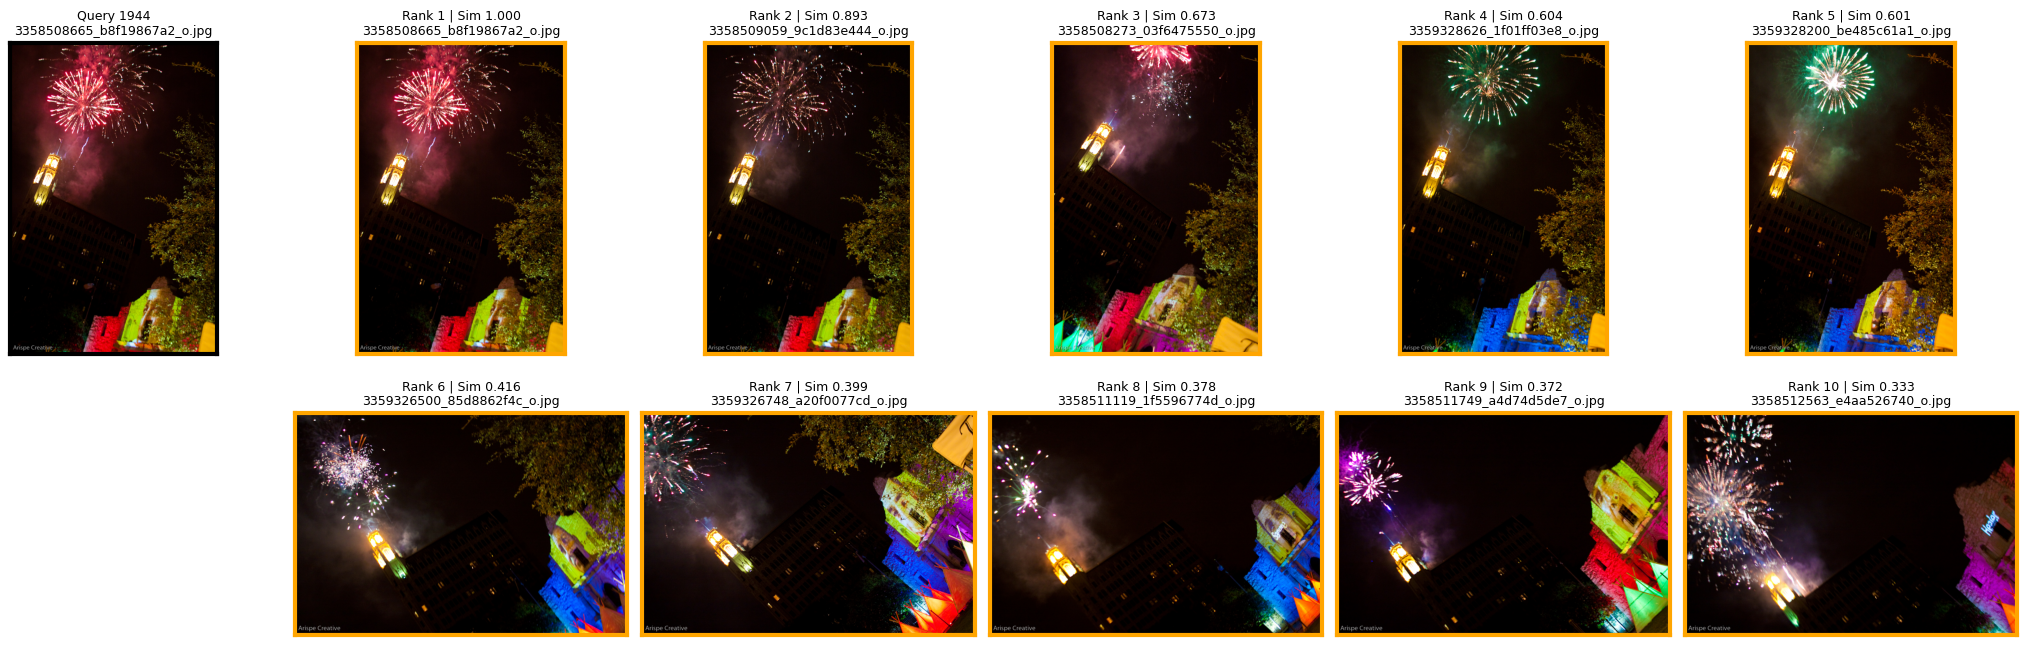

Query 1944 has no ground truth.


In [34]:
# 随机可视化一个查询的检索结果
visualize_retrieval(state, query_idx=None, topk=RANDOM_TOPK, grid=(2, 5))

In [30]:
# 按文件名可视化检索结果
QUERY_NAME = ''  # 例如: '000123.jpg' 或路径子串
if QUERY_NAME:
    # 查找对应query_idx
    query_idx = next((i for i, p in enumerate(state['query_paths']) if QUERY_NAME in str(p)), None)
    if query_idx is not None:
        visualize_retrieval(state, query_idx=query_idx, topk=RANDOM_TOPK, grid=(2, 5))
    else:
        print(f'未找到包含 "{QUERY_NAME}" 的查询图片。')
else:
    print('请设置 QUERY_NAME 并重新运行本单元。')

请设置 QUERY_NAME 并重新运行本单元。


In [ ]:
# 外部输入图像检索
INPUT_IMAGE = ''  # 支持仓库内或外部图像路径
if INPUT_IMAGE:
    # 需实现 visualize_external_image，或参考 verify_eval_university1652.ipynb 的外部图像处理逻辑
    try:
        visualize_external_image(state, INPUT_IMAGE, topk=RANDOM_TOPK)
    except Exception as e:
        print(f'外部图像检索失败: {e}')
else:
    print('请设置 INPUT_IMAGE 并重新运行本单元。')